## 1. Carga y Exploración de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
# Cargar datasets
RATINGS_PATH = "file.tsv"
TITLES_PATH  = "Movie_Id_Titles.csv"

ratings_cols = ["user_id", "item_id", "rating", "timestamp"]
ratings = pd.read_csv(RATINGS_PATH, sep="\t", header=None, names=ratings_cols, engine="python")
titles = pd.read_csv(TITLES_PATH)

In [24]:
# Unir calificaciones con títulos
df = ratings.merge(titles, on="item_id", how="left")

n_users = df["user_id"].nunique()
n_items = df["item_id"].nunique()

print(f"Nº de usuarios: {n_users}")
print(f"Nº de películas: {n_items}")
print(f"Nº de registros: {len(df)}\n")

print(df.head())

Nº de usuarios: 944
Nº de películas: 1682
Nº de registros: 100003

   user_id  item_id  rating  timestamp                            title
0        0       50       5  881250949                 Star Wars (1977)
1        0      172       5  881250949  Empire Strikes Back, The (1980)
2        0      133       1  881250949        Gone with the Wind (1939)
3      196      242       3  881250949                     Kolya (1996)
4      186      302       3  891717742         L.A. Confidential (1997)


In [25]:
# Películas con mayor número de calificaciones (Top 5)
pop_counts = df.groupby(["item_id", "title"], as_index=False)["rating"].count() \
               .rename(columns={"rating": "num_ratings"})
print("\nTop 5 películas por número de calificaciones:")
print(pop_counts.sort_values("num_ratings", ascending=False).head(5))


Top 5 películas por número de calificaciones:
     item_id                      title  num_ratings
49        50           Star Wars (1977)          584
257      258             Contact (1997)          509
99       100               Fargo (1996)          508
180      181  Return of the Jedi (1983)          507
293      294           Liar Liar (1997)          485


## 2. Recomendación Basada en Popularidad

Top-10 por popularidad (número de calificaciones y media):
     item_id                          title  num_ratings  mean_rating
49        50               Star Wars (1977)          584     4.359589
257      258                 Contact (1997)          509     3.803536
99       100                   Fargo (1996)          508     4.155512
180      181      Return of the Jedi (1983)          507     4.007890
293      294               Liar Liar (1997)          485     3.156701
285      286    English Patient, The (1996)          481     3.656965
287      288                  Scream (1996)          478     3.441423
0          1               Toy Story (1995)          452     3.878319
299      300           Air Force One (1997)          431     3.631090
120      121  Independence Day (ID4) (1996)          429     3.438228


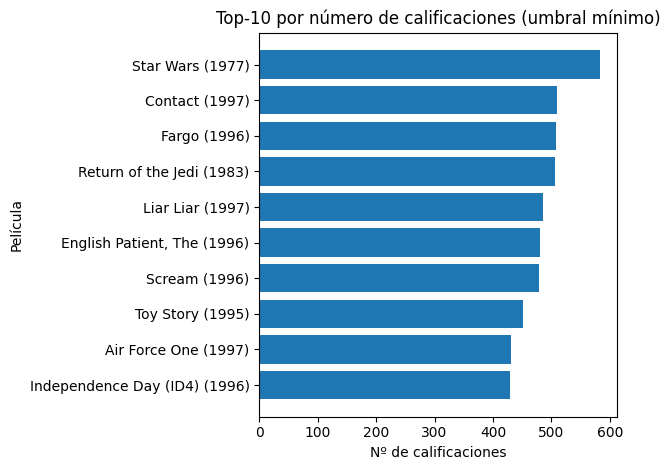

In [26]:
# Calcular número de calificaciones y media por película
agg = df.groupby(["item_id", "title"]).agg(
    num_ratings=("rating", "count"),
    mean_rating=("rating", "mean")
).reset_index()

# Definir un umbral mínimo de votos para evitar sesgos de películas con pocas calificaciones
min_votes = 100
popular = agg[agg["num_ratings"] >= min_votes] \
            .sort_values(["num_ratings", "mean_rating"], ascending=False)

# Seleccionar el Top-10 de películas
top10_pop = popular.head(10)

print("Top-10 por popularidad (número de calificaciones y media):")
print(top10_pop)

# Visualizar con gráfico de barras
plt.figure()
plt.barh(top10_pop["title"].iloc[::-1], top10_pop["num_ratings"].iloc[::-1])
plt.title("Top-10 por número de calificaciones (umbral mínimo)")
plt.xlabel("Nº de calificaciones")
plt.ylabel("Película")
plt.tight_layout()
plt.show()

## 3. Filtrado Colaborativo Basado en usuarios

Recomendaciones CF-Usuarios para usuario 0:
   item_id                                      title     score
0      181                  Return of the Jedi (1983)  3.044553
1      174             Raiders of the Lost Ark (1981)  1.810290
2      210  Indiana Jones and the Last Crusade (1989)  1.628384
3        1                           Toy Story (1995)  1.495178
4      258                             Contact (1997)  1.391573
5      195                     Terminator, The (1984)  1.269376
6       56                        Pulp Fiction (1994)  1.239975
7      127                      Godfather, The (1972)  1.239578
8      187             Godfather: Part II, The (1974)  1.202557
9      168     Monty Python and the Holy Grail (1974)  1.174243


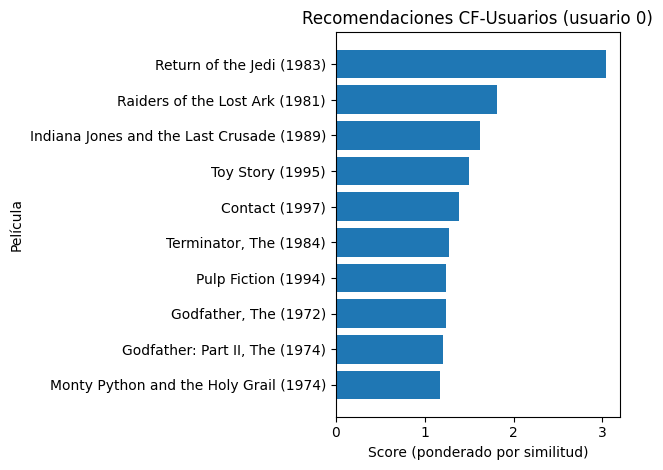

In [27]:
# Crear la matriz usuario–ítem
user_item = df.pivot_table(index="user_id", columns="item_id", values="rating")

# Rellenar NaN con 0 para poder calcular similitud del coseno
user_item_filled = user_item.fillna(0.0)

# Calcular matriz de similitud coseno entre usuarios
def calcular_similitud_usuarios(matrix_filled: pd.DataFrame) -> pd.DataFrame:
    sim = cosine_similarity(matrix_filled.values)
    return pd.DataFrame(sim, index=matrix_filled.index, columns=matrix_filled.index)

user_sim = calcular_similitud_usuarios(user_item_filled)

# Función para recomendar películas a un usuario basándose en vecinos similares
def recomendar_usuario(user_id: int,
                       matrix_filled: pd.DataFrame,
                       sim_mat: pd.DataFrame,
                       titles_df: pd.DataFrame,
                       top_k_vecinos: int = 20,
                       top_n: int = 10) -> pd.DataFrame:
    if user_id not in matrix_filled.index:
        raise ValueError("Usuario no encontrado en la matriz.")

    # Obtener similitudes del usuario objetivo con otros
    sims = sim_mat.loc[user_id].drop(labels=[user_id])
    vecinos = sims.sort_values(ascending=False).head(top_k_vecinos)

    # Obtener calificaciones de vecinos
    ratings_vecinos = matrix_filled.loc[vecinos.index]

    # Ponderar calificaciones por similitud
    weights = vecinos.values.reshape(-1, 1)
    puntuaciones = np.dot(weights.T, ratings_vecinos.values) / (np.abs(weights).sum() + 1e-8)

    # Convertir a serie con índice de ítems
    punt_series = pd.Series(puntuaciones.ravel(), index=ratings_vecinos.columns, name="score")

    # Excluir películas ya vistas por el usuario
    ya_vistos = matrix_filled.loc[user_id]
    candidatos = punt_series[ya_vistos == 0].sort_values(ascending=False)

    # Preparar dataframe final con títulos
    recs = candidatos.head(top_n).reset_index().rename(columns={"index": "item_id"})
    recs = recs.merge(titles_df, on="item_id", how="left")
    return recs[["item_id", "title", "score"]]

# Ejemplo de uso con un usuario del dataset (usar el primero)
usuario_ejemplo = int(user_item_filled.index[0])
recs_user = recomendar_usuario(usuario_ejemplo, user_item_filled, user_sim, titles,
                                top_k_vecinos=20, top_n=10)

print(f"Recomendaciones CF-Usuarios para usuario {usuario_ejemplo}:")
print(recs_user)

# Visualizar resultados
import matplotlib.pyplot as plt

plt.figure()
plt.barh(recs_user["title"].iloc[::-1], recs_user["score"].iloc[::-1])
plt.title(f"Recomendaciones CF-Usuarios (usuario {usuario_ejemplo})")
plt.xlabel("Score (ponderado por similitud)")
plt.ylabel("Película")
plt.tight_layout()
plt.show()

## 4. Filtrado Colaborativo Basado en Ítems

Recomendaciones CF-Ítems para usuario 0:
   item_id                                      title     score
0      174             Raiders of the Lost Ark (1981)  8.473545
1      181                  Return of the Jedi (1983)  8.117587
2      204                  Back to the Future (1985)  7.684066
3       98           Silence of the Lambs, The (1991)  7.386777
4      210  Indiana Jones and the Last Crusade (1989)  7.331078
5      423          E.T. the Extra-Terrestrial (1982)  7.162517
6      168     Monty Python and the Holy Grail (1974)  7.113276
7       69                        Forrest Gump (1994)  7.060532
8      195                     Terminator, The (1984)  6.992093
9      173                 Princess Bride, The (1987)  6.854336


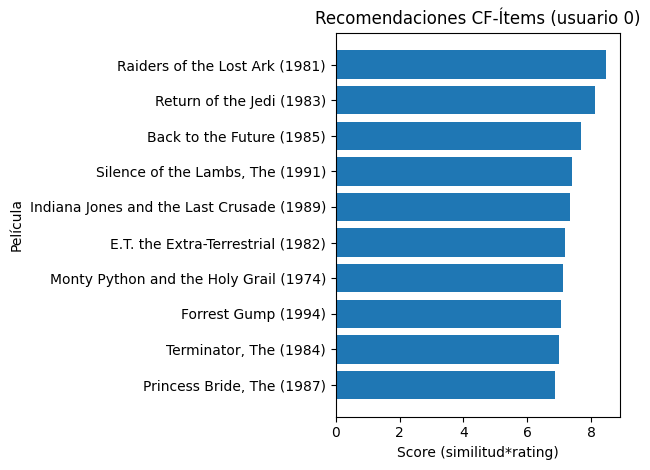

In [28]:
# Transponer la matriz usuario–ítem para obtener matriz ítem–usuario
item_user_filled = user_item_filled.T  # filas = ítems, columnas = usuarios

# Calcular similitud coseno entre ítems
item_sim = cosine_similarity(item_user_filled.values)
item_sim = pd.DataFrame(item_sim, index=item_user_filled.index, columns=item_user_filled.index)

# Función para recomendar ítems similares a los que el usuario ha valorado
def recomendar_item(user_id: int,
                    matrix_filled: pd.DataFrame,
                    item_sim_mat: pd.DataFrame,
                    titles_df: pd.DataFrame,
                    agg_pop_df: pd.DataFrame,
                    top_k_similares: int = 40,
                    top_n: int = 10) -> pd.DataFrame:
    if user_id not in matrix_filled.index:
        raise ValueError("Usuario no encontrado en la matriz.")

    # Obtener historial del usuario
    ratings_u = matrix_filled.loc[user_id]
    vistos = ratings_u[ratings_u > 0]

    # Si no hay historial, devolver películas populares (fallback)
    if vistos.empty:
        populares = agg_pop_df.sort_values(["num_ratings", "mean_rating"], ascending=False).head(top_n)
        return populares[["item_id", "title"]].assign(score=populares["mean_rating"].values)

    # Calcular puntuaciones por similitud
    scores = pd.Series(0.0, index=matrix_filled.columns)
    for item_visto, r in vistos.items():
        similares = item_sim_mat.loc[item_visto].drop(item_visto).sort_values(ascending=False).head(top_k_similares)
        scores.loc[similares.index] += similares.values * r

    # Excluir ítems ya vistos por el usuario
    scores = scores[ratings_u == 0].sort_values(ascending=False)

    # Preparar dataframe final con títulos
    recs = scores.head(top_n).rename("score").reset_index().rename(columns={"index": "item_id"})
    recs = recs.merge(titles_df, on="item_id", how="left")
    return recs[["item_id", "title", "score"]]

# Ejemplo de uso con el mismo usuario de antes
# Necesitamos la tabla 'agg' de popularidad para el fallback
agg = df.groupby(["item_id", "title"]).agg(
    num_ratings=("rating", "count"),
    mean_rating=("rating", "mean")
).reset_index()

recs_item = recomendar_item(usuario_ejemplo, user_item_filled, item_sim, titles, agg,
                             top_k_similares=40, top_n=10)

print(f"Recomendaciones CF-Ítems para usuario {usuario_ejemplo}:")
print(recs_item)

# Visualizar resultados
plt.figure()
plt.barh(recs_item["title"].iloc[::-1], recs_item["score"].iloc[::-1])
plt.title(f"Recomendaciones CF-Ítems (usuario {usuario_ejemplo})")
plt.xlabel("Score (similitud*rating)")
plt.ylabel("Película")
plt.tight_layout()
plt.show()

## 5. Visualización de Resultados

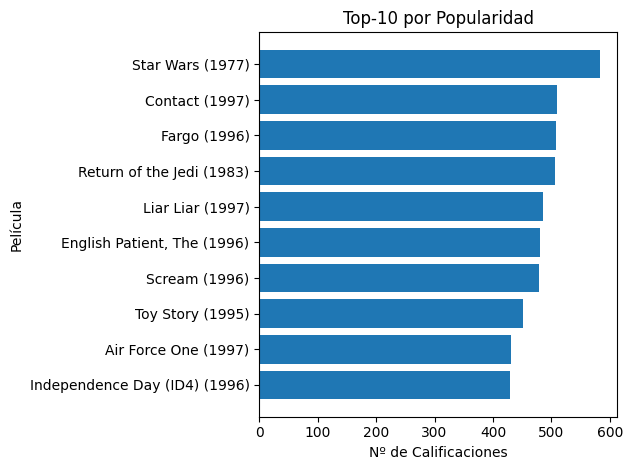

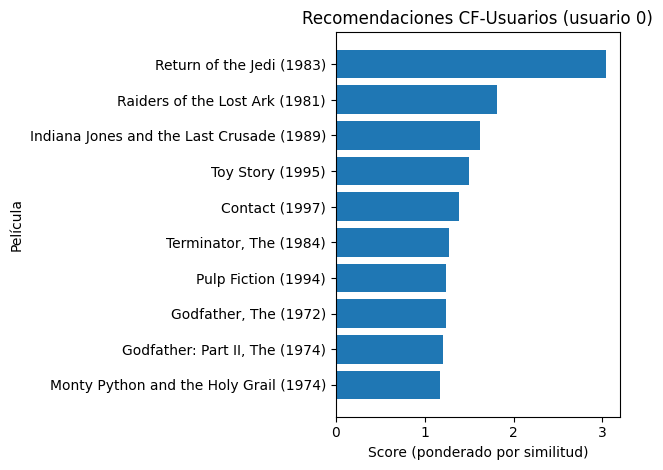

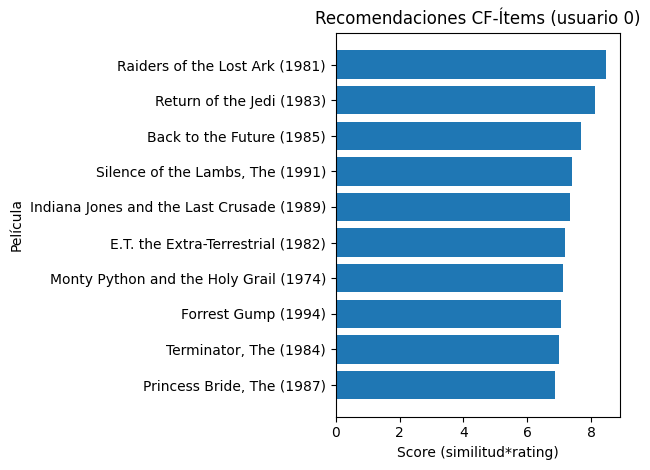

Comparación Cualitativa:
Popularidad: simple, robusto, no personalizado.
CF-Usuarios: personalizado, depender de densidad de datos del usuario.
CF-Ítems: estable, bueno con suficiente superposición de calificaciones.


In [30]:
# Crear función auxiliar para mostrar gráficos de barras horizontales
def plot_topn(df_recs, title, xlabel, ylabel="Película"):
    plt.figure()
    plt.barh(df_recs["title"].iloc[::-1], df_recs["score"].iloc[::-1])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# Visualizar Popularidad
plot_topn(
    top10_pop.rename(columns={"num_ratings": "score"}),
    title="Top-10 por Popularidad",
    xlabel="Nº de Calificaciones"
)

# Visualizar CF-Usuarios
plot_topn(
    recs_user,
    title=f"Recomendaciones CF-Usuarios (usuario {usuario_ejemplo})",
    xlabel="Score (ponderado por similitud)"
)

# Visualizar CF-Ítems
plot_topn(
    recs_item,
    title=f"Recomendaciones CF-Ítems (usuario {usuario_ejemplo})",
    xlabel="Score (similitud*rating)"
)

# Comparación rápida (texto)
print("Comparación Cualitativa:")
print("Popularidad: simple, robusto, no personalizado.")
print("CF-Usuarios: personalizado, depender de densidad de datos del usuario.")
print("CF-Ítems: estable, bueno con suficiente superposición de calificaciones.")


# Informe

Este trabajo construye tres recomendadores sencillos con pandas usando los ficheros file.tsv (ratings) y Movie_Id_Titles.csv (títulos). Primero uní por item_id, comprobé tipos y nulos, e hice una EDA rápida (número de usuarios, ítems y distribución de notas). Después implementé:  popularidad, ordenando películas por número de calificaciones con un umbral mínimo para evitar sesgos; filtrado colaborativo basado en usuarios, creando la matriz usuario–ítem, calculando similitud coseno entre usuarios y recomendando con un promedio ponderado por similitud; y filtrado colaborativo basado en ítems, calculando similitud entre películas y puntuando candidatas como suma de (similitud × rating) respecto a los ítems ya valorados.

Los resultados fueron consistentes: popularidad devuelve un Top-10 de títulos muy conocidos y estable; el CF-usuarios recomendó obras acordes al perfil (misma saga/tema); el CF-ítems fue estable y coherente con los gustos del usuario de ejemplo. Cuando no hay historial del usuario, usé popularidad como “fallback”. Importante: las escalas de “score” difieren entre métodos, así que lo relevante es el ranking, no comparar valores absolutos.

En la comparación, popularidad es simple y robusto pero no personaliza; CF-usuarios personaliza bien si el usuario tiene suficientes valoraciones; CF-ítems tiende a ser más estable y también personaliza con algo de solapamiento. Como mejora rápida propondría probar Pearson centrado por usuario, ajustar el umbral de votos y el número de vecinos/ítems similares, y añadir una métrica offline de ranking.